# 03 — Train Super-Resolution CNN

Trains a small ESPCN-style CNN to upscale LR tiles to HR.
Evaluates against bicubic baseline using PSNR and SSIM.

**Each run is saved to `experiments/{EXP_NAME}/`** — change the config at the top, change the name, re-run. Previous experiments are preserved.

In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from model import SuperResCNN, PerceptualLoss
from dataset import SRDataset
from degrade import bicubic_upscale

%matplotlib inline

# ============================================================
# EXPERIMENT CONFIG — change these, change EXP_NAME, re-run
# ============================================================
EXP_NAME = 'v3_more_data_4x'

CONFIG = {
    'scale':             4,
    'n_resblocks':       6,
    'n_feats':           96,
    'batch_size':        16,
    'lr':                5e-4,
    'epochs':            200,
    'patience':          15,
    'perceptual_weight': 0.01,
    'manifest':          '../data/manifest.csv',
}
# ============================================================

EXP_DIR = Path(f'../experiments/{EXP_NAME}')
EXP_DIR.mkdir(parents=True, exist_ok=True)

# Save config
with open(EXP_DIR / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Experiment: {EXP_NAME}')
print(f'Device:     {DEVICE}')
print(f'Config:     {CONFIG}')

Experiment: v3_more_data_4x
Device:     mps
Config:     {'scale': 4, 'n_resblocks': 6, 'n_feats': 96, 'batch_size': 16, 'lr': 0.0005, 'epochs': 200, 'patience': 15, 'perceptual_weight': 0.01, 'manifest': '../data/manifest.csv'}


## Step 1: Load datasets

In [2]:
train_ds = SRDataset(CONFIG['manifest'], split='train', augment=True)
val_ds   = SRDataset(CONFIG['manifest'], split='val',   augment=False)
test_ds  = SRDataset(CONFIG['manifest'], split='test',  augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

Train: 1712  Val: 301  Test: 282


## Step 2: Create model

In [3]:
model = SuperResCNN(
    scale=CONFIG['scale'],
    n_resblocks=CONFIG['n_resblocks'],
    n_feats=CONFIG['n_feats'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

l1_loss = nn.L1Loss()
perceptual_loss = PerceptualLoss().to(DEVICE) if CONFIG['perceptual_weight'] > 0 else None

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

Parameters: 1,040,688


## Step 3: Train

In [4]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_state = model.state_dict()
wait = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    # -- Train --
    model.train()
    epoch_loss = 0.0
    for lr, hr in train_loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        pred = model(lr)
        loss = l1_loss(pred, hr)
        if perceptual_loss is not None:
            loss = loss + CONFIG['perceptual_weight'] * perceptual_loss(pred, hr)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * lr.size(0)
    train_losses.append(epoch_loss / len(train_ds))

    # -- Validate (L1 only for comparable tracking) --
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for lr, hr in val_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            pred = model(lr)
            val_loss += l1_loss(pred, hr).item() * lr.size(0)
    val_losses.append(val_loss / len(val_ds))

    scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{CONFIG["epochs"]}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  lr={lr_now:.1e}')

    if wait >= CONFIG['patience']:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {CONFIG["patience"]} epochs)')
        break

model.load_state_dict(best_state)
model.to(DEVICE)
print(f'\nBest val loss: {best_val_loss:.4f}')

Epoch   1/200  train=0.0754  val=0.0552  lr=5.0e-04
Epoch  10/200  train=0.0486  val=0.0498  lr=5.0e-04
Epoch  20/200  train=0.0473  val=0.0484  lr=5.0e-04
Epoch  30/200  train=0.0465  val=0.0476  lr=5.0e-04
Epoch  40/200  train=0.0460  val=0.0472  lr=5.0e-04
Epoch  50/200  train=0.0456  val=0.0467  lr=5.0e-04
Epoch  60/200  train=0.0452  val=0.0465  lr=5.0e-04
Epoch  70/200  train=0.0450  val=0.0463  lr=5.0e-04
Epoch  80/200  train=0.0448  val=0.0460  lr=5.0e-04
Epoch  90/200  train=0.0446  val=0.0461  lr=5.0e-04
Epoch 100/200  train=0.0444  val=0.0460  lr=5.0e-04
Epoch 110/200  train=0.0443  val=0.0458  lr=5.0e-04
Epoch 120/200  train=0.0441  val=0.0457  lr=5.0e-04
Epoch 130/200  train=0.0440  val=0.0459  lr=5.0e-04
Epoch 140/200  train=0.0435  val=0.0456  lr=2.5e-04
Epoch 150/200  train=0.0434  val=0.0456  lr=2.5e-04
Epoch 160/200  train=0.0431  val=0.0455  lr=1.3e-04
Epoch 170/200  train=0.0430  val=0.0455  lr=6.3e-05
Epoch 180/200  train=0.0429  val=0.0455  lr=6.3e-05

Early stopp

## Step 4: Loss curves

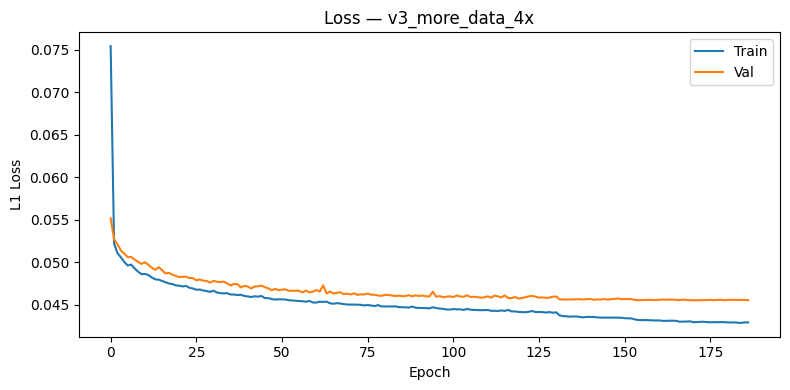

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss')
ax.set_title(f'Loss — {EXP_NAME}')
ax.legend()
plt.tight_layout()
fig.savefig(EXP_DIR / 'loss_curves.png', bbox_inches='tight')
plt.show()

# Save raw loss values
with open(EXP_DIR / 'losses.json', 'w') as f:
    json.dump({'train': train_losses, 'val': val_losses}, f)

## Step 5: Evaluate on test set

Compare CNN output vs bicubic baseline, both measured against HR ground truth using PSNR and SSIM.

In [6]:
model.eval()

cnn_psnr, cnn_ssim = [], []
bic_psnr, bic_ssim = [], []

with torch.no_grad():
    for lr, hr in test_loader:
        pred = model(lr.to(DEVICE)).cpu()
        for i in range(lr.size(0)):
            hr_np   = (hr[i].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            pred_np = (pred[i].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            lr_np   = (lr[i].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            bic_np  = bicubic_upscale(lr_np, scale=CONFIG['scale'])

            cnn_psnr.append(psnr(hr_np, pred_np, data_range=255))
            cnn_ssim.append(ssim(hr_np, pred_np, data_range=255, channel_axis=2))
            bic_psnr.append(psnr(hr_np, bic_np, data_range=255))
            bic_ssim.append(ssim(hr_np, bic_np, data_range=255, channel_axis=2))

results = {
    'bicubic_psnr': float(np.mean(bic_psnr)),
    'bicubic_ssim': float(np.mean(bic_ssim)),
    'cnn_psnr':     float(np.mean(cnn_psnr)),
    'cnn_ssim':     float(np.mean(cnn_ssim)),
    'delta_psnr':   float(np.mean(cnn_psnr) - np.mean(bic_psnr)),
    'delta_ssim':   float(np.mean(cnn_ssim) - np.mean(bic_ssim)),
}

with open(EXP_DIR / 'metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'{"Method":<12} {"PSNR (dB)":>10} {"SSIM":>10}')
print(f'{"Bicubic":<12} {results["bicubic_psnr"]:>10.2f} {results["bicubic_ssim"]:>10.4f}')
print(f'{"CNN":<12} {results["cnn_psnr"]:>10.2f} {results["cnn_ssim"]:>10.4f}')
print(f'{"CNN - Bic":<12} {results["delta_psnr"]:>+10.2f} {results["delta_ssim"]:>+10.4f}')
print(f'\nSaved to {EXP_DIR / "metrics.json"}')

Method        PSNR (dB)       SSIM
Bicubic           22.24     0.5010
CNN               23.14     0.6160
CNN - Bic         +0.90    +0.1150

Saved to ../experiments/v3_more_data_4x/metrics.json


## Step 6: Visual comparison

Side-by-side: LR | Bicubic | CNN | HR ground truth

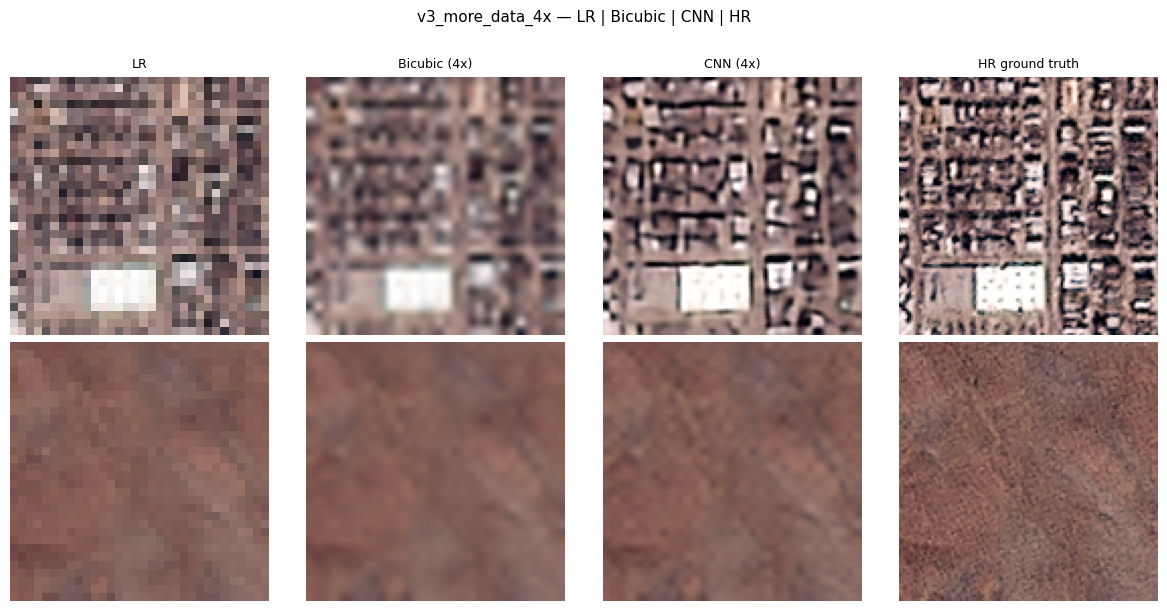

In [7]:
# Show one sample per AOI from the test set
import pandas as pd

model.eval()
manifest = pd.read_csv(CONFIG['manifest'])
test_manifest = manifest[manifest['split'] == 'test']
aois = sorted(test_manifest['aoi'].unique())

fig, axes = plt.subplots(len(aois), 4, figsize=(12, 3 * len(aois)))
col_titles = ['LR', f'Bicubic ({CONFIG["scale"]}x)', f'CNN ({CONFIG["scale"]}x)', 'HR ground truth']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9)

for row, aoi in enumerate(aois):
    sample = test_manifest[test_manifest['aoi'] == aoi].iloc[0]
    lr_np = np.array(Image.open(sample['lr_path']))
    hr_np = np.array(Image.open(sample['hr_path']))
    bic_np = bicubic_upscale(lr_np, scale=CONFIG['scale'])

    lr_t = torch.from_numpy(lr_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    with torch.no_grad():
        pred_t = model(lr_t.to(DEVICE)).cpu()
    pred_np = (pred_t[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

    for ax, img in zip(axes[row], [lr_np, bic_np, pred_np, hr_np]):
        ax.imshow(img)
        ax.axis('off')
    axes[row, 0].set_ylabel(aoi, fontsize=8, rotation=90, labelpad=40)

plt.suptitle(f'{EXP_NAME} — LR | Bicubic | CNN | HR', fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(EXP_DIR / 'comparison.png', bbox_inches='tight')
plt.show()

## Step 7: Save model

In [8]:
torch.save(model.state_dict(), EXP_DIR / 'model.pth')
print(f'Model saved to {EXP_DIR / "model.pth"}')

Model saved to ../experiments/v3_more_data_4x/model.pth
